# 07 - Vulnerability Similarity Search

This notebook implements a semantic similarity search system for CVE descriptions using Sentence-BERT embeddings.

Users can input a vulnerability description and find the most similar CVEs in the database.

Model: `all-MiniLM-L6-v2` (fast, good quality)

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import sys
sys.path.append('..')

plt.rcParams['figure.figsize'] = (12, 6)

/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Load Data and Model

In [2]:
df = pd.read_csv('../data/cve_with_keywords.csv')
print(f"Loaded {len(df)} CVE records")

# Load Sentence-BERT model
print("Loading Sentence-BERT model (all-MiniLM-L6-v2)...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

Loaded 1314 CVE records
Loading Sentence-BERT model (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


## 2. Generate Embeddings for All CVEs

In [3]:
# Generate embeddings for all CVE descriptions
descriptions = df['Description'].fillna('').tolist()

print("Generating embeddings for all CVE descriptions...")
embeddings = sbert_model.encode(descriptions, show_progress_bar=True, batch_size=32)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")

Generating embeddings for all CVE descriptions...


Batches:   0%|          | 0/42 [00:00<?, ?it/s]

Embeddings shape: (1314, 384)
Embedding dimension: 384


## 3. Similarity Search Function

In [4]:
def find_similar_cves(query, embeddings, df, model, top_n=5):
    """Find the most similar CVEs to a given query description."""
    # Encode the query
    query_embedding = model.encode([query])

    # Calculate cosine similarity
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    # Get top-N most similar (excluding exact matches)
    top_indices = similarities.argsort()[::-1][:top_n]

    results = []
    for idx in top_indices:
        results.append({
            'CVE ID': df['CVE ID'].iloc[idx],
            'Description': df['Description'].iloc[idx],
            'CVSS Score': df['CVSS Score'].iloc[idx],
            'Severity': df['Severity'].iloc[idx],
            'Vulnerability_Type': df['Vulnerability_Type'].iloc[idx],
            'Similarity': similarities[idx]
        })

    return pd.DataFrame(results)

## 4. Demo: Find Similar CVEs

In [5]:
# Test with different queries
test_queries = [
    "SQL injection vulnerability in login page",
    "Buffer overflow allowing remote code execution",
    "Cross-site scripting in WordPress plugin",
    "Denial of service attack through crafted network packets",
    "Privilege escalation vulnerability in Linux kernel"
]

for query in test_queries:
    print(f"\n{'='*80}")
    print(f"QUERY: {query}")
    print(f"{'='*80}")

    results = find_similar_cves(query, embeddings, df, sbert_model, top_n=3)

    for i, row in results.iterrows():
        print(f"\n  #{i+1} [{row['CVE ID']}] (Similarity: {row['Similarity']:.4f})")
        print(f"      Type: {row['Vulnerability_Type']} | Severity: {row['Severity']} | CVSS: {row['CVSS Score']}")
        print(f"      {row['Description'][:150]}...")


QUERY: SQL injection vulnerability in login page


/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



  #1 [CVE-2023-50752] (Similarity: 0.6749)
      Type: SQL Injection | Severity: Critical | CVSS: 9.8
      Online Notice Board System v1.0 is vulnerable to multiple Unauthenticated SQL Injection vulnerabilities. The 'e' parameter of the login.php resource d...

  #2 [CVE-2024-0474] (Similarity: 0.6728)
      Type: SQL Injection | Severity: High | CVSS: 7.3
      A vulnerability classified as critical was found in code-projects Dormitory Management System 1.0. Affected by this vulnerability is an unknown functi...

  #3 [CVE-2024-0267] (Similarity: 0.6606)
      Type: SQL Injection | Severity: High | CVSS: 7.3
      A vulnerability classified as critical was found in Kashipara Hospital Management System up to 1.0. Affected by this vulnerability is an unknown funct...

QUERY: Buffer overflow allowing remote code execution

  #1 [CVE-2024-21318] (Similarity: 0.5992)
      Type: Remote Code Execution | Severity: High | CVSS: 8.8
      Microsoft SharePoint Server Remote Code Execution Vul

/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



  #1 [CVE-2023-6882] (Similarity: 0.5661)
      Type: Cross-Site Scripting (XSS) | Severity: Medium | CVSS: 6.1
      The Simple Membership plugin for WordPress is vulnerable to Reflected Cross-Site Scripting via the ‘environment_mode’ parameter in all versions up to,...

  #2 [CVE-2023-6747] (Similarity: 0.5322)
      Type: Cross-Site Scripting (XSS) | Severity: Medium | CVSS: 6.4
      The Best WordPress Gallery Plugin – FooGallery plugin for WordPress is vulnerable to Stored Cross-Site Scripting via the custom attributes in all vers...

  #3 [CVE-2023-6624] (Similarity: 0.5143)
      Type: Cross-Site Scripting (XSS) | Severity: Medium | CVSS: 4.9
      The Import and export users and customers plugin for WordPress is vulnerable to Stored Cross-Site Scripting via the plugin's shortcode(s) in all versi...

QUERY: Denial of service attack through crafted network packets

  #1 [CVE-2024-20672] (Similarity: 0.5921)
      Type: Denial of Service | Severity: High | CVSS: 7.5
      .NET De

/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 5. Similarity Distribution Analysis

/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


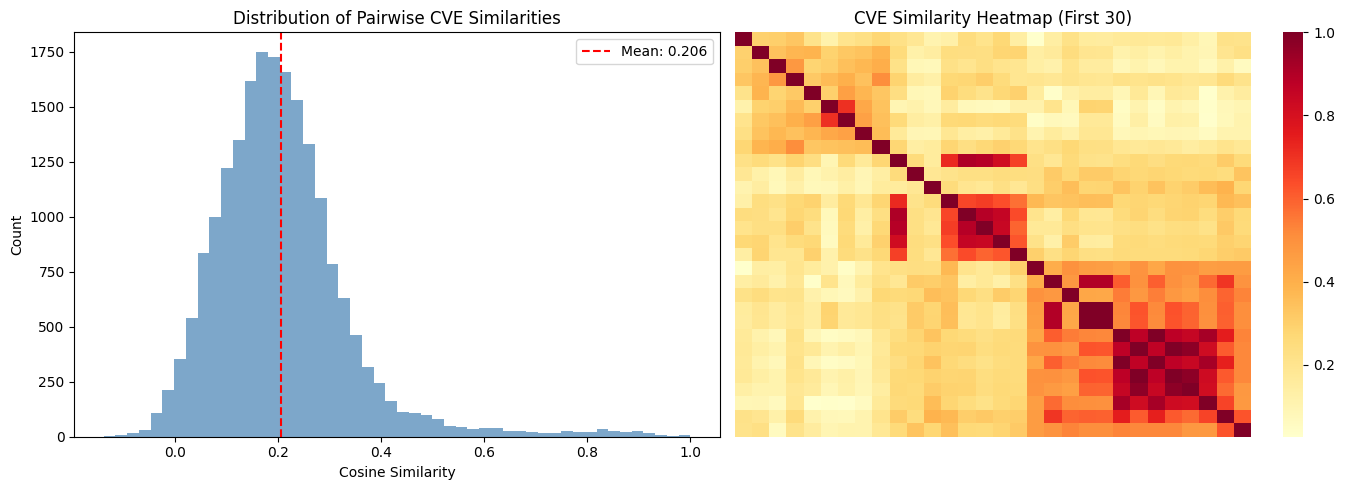

Mean pairwise similarity: 0.2060
Highly similar pairs (>0.8): 158
Very similar pairs (>0.9): 44


In [6]:
# Compute pairwise similarities for a sample
sample_size = min(200, len(embeddings))
sample_embeddings = embeddings[:sample_size]
sim_matrix = cosine_similarity(sample_embeddings)

# Get upper triangle (exclude diagonal)
upper_tri = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of pairwise similarities
axes[0].hist(upper_tri, bins=50, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Pairwise CVE Similarities')
axes[0].axvline(upper_tri.mean(), color='red', linestyle='--',
                label=f'Mean: {upper_tri.mean():.3f}')
axes[0].legend()

# Heatmap of similarity matrix (first 30)
sns.heatmap(sim_matrix[:30, :30], cmap='YlOrRd', ax=axes[1],
            xticklabels=False, yticklabels=False)
axes[1].set_title('CVE Similarity Heatmap (First 30)')

plt.tight_layout()
plt.show()

print(f"Mean pairwise similarity: {upper_tri.mean():.4f}")
print(f"Highly similar pairs (>0.8): {(upper_tri > 0.8).sum()}")
print(f"Very similar pairs (>0.9): {(upper_tri > 0.9).sum()}")

## 6. Similarity by Vulnerability Type

Average Intra-Class Similarity by Vulnerability Type:
  SQL Injection                       0.5649
  Path Traversal                      0.4510
  CSRF                                0.4211
  Cross-Site Scripting (XSS)          0.4161
  Buffer Overflow                     0.3972
  Command Injection                   0.3951
  Privilege Escalation                0.3745
  SSRF                                0.3675
  Remote Code Execution               0.2890
  Information Disclosure              0.2842
  Authentication Bypass               0.2728
  Denial of Service                   0.2647


/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: d

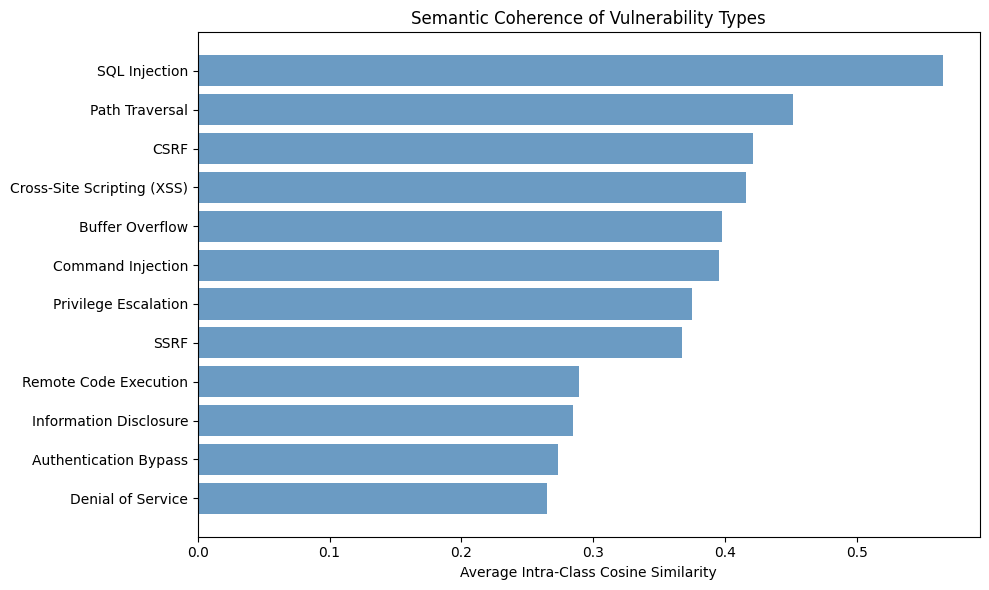

In [7]:
# Intra-class similarity: how similar are CVEs within the same vulnerability type?
vuln_types = df['Vulnerability_Type'].unique()
vuln_types = [v for v in vuln_types if v != 'Other']

intra_similarities = {}
for vtype in vuln_types:
    mask = df['Vulnerability_Type'] == vtype
    type_indices = np.where(mask)[0]
    if len(type_indices) < 3:
        continue
    type_embeddings = embeddings[type_indices]
    type_sim = cosine_similarity(type_embeddings)
    upper = type_sim[np.triu_indices_from(type_sim, k=1)]
    if len(upper) > 0:
        intra_similarities[vtype] = upper.mean()

print("Average Intra-Class Similarity by Vulnerability Type:")
for vtype, sim in sorted(intra_similarities.items(), key=lambda x: -x[1]):
    print(f"  {vtype:35s} {sim:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
sorted_types = sorted(intra_similarities.items(), key=lambda x: x[1])
plt.barh([t[0] for t in sorted_types], [t[1] for t in sorted_types],
         color='steelblue', alpha=0.8)
plt.xlabel('Average Intra-Class Cosine Similarity')
plt.title('Semantic Coherence of Vulnerability Types')
plt.tight_layout()
plt.show()

## 7. Save Embeddings

In [8]:
# Save embeddings for use in the Streamlit app
np.save('../models/cve_embeddings.npy', embeddings)

print(f"Saved embeddings: {embeddings.shape}")
print("  - models/cve_embeddings.npy")
print("\n✅ Similarity search system complete!")

Saved embeddings: (1314, 384)
  - models/cve_embeddings.npy

✅ Similarity search system complete!
